# Solute Transport Toy: mPCN joint vs pCN chains

Compare one mPCN chain with P proposals to P independent pCN chains, plus a MESS baseline with M=P.
Includes pairplots and traceplots.

In [ ]:
import os
import sys
from pathlib import Path
import time
import json
import hashlib
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import get_context

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.plotting.diagnostics import make_hist_grid_comps
from multiproposal.utils.run_paths import build_run_dirs, format_float_tag
from reports.figure_style import apply_pub_style

In [54]:
# Solute transport configuration
seed_data = 0
seed_mcmc = 202

d = 20
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data

obs_highest_freq = 8
obs_bandwidth = 5
obs_config = 'central_modes'

print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

d: 20
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [57]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag, label):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f'{label} runtime (min): {runtime_min:.2f}')
    print(f'{label} mean ESS: {ess_mean:.1f}')
    print(f'{label} mean MSJD: {msjd_mean:.4g}')
    print(f'{label} ESS per minute: {ess_per_min:.2f}')
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
        'ess_per_param': ess_vals.tolist(),
        'msjd_per_param': msjd_vals.tolist(),
    }

In [58]:
# Shared-draws helpers (same as the solute transport sweep notebook)
datasets_by_dim = {}

def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)


def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]


def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
 ):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}')
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset)
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }


def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }


def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [59]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
 )
problem, a_init, data = build_problem_for_dim(d, shared_draws)
x0 = a_init.copy()
prior_cov = np.diag(data['prior_diag'])
prior_sample = data.get('a_true', None)

print('Shared draws ready with d:', d)
print('Parameter dim:', problem.dim)
print('Initial x0 norm:', np.linalg.norm(x0))

Shared draws ready with d: 20
Parameter dim: 190
Initial x0 norm: 0.22733654049403187


In [60]:
# MCMC configuration
n_iters = 30000
rho = 0.93
P_joint = 20
num_pcn_chains = P_joint
mess_M = P_joint
run_mess = True
run_pcn = True
burn_in = 2000
max_lag = 1500

pcn_thin_step = max(1, num_pcn_chains)
pcn_max_workers = min(num_pcn_chains, os.cpu_count() or 1)

print('n_iters:', n_iters)
print('rho:', rho)
print('P_joint:', P_joint)
print('num_pcn_chains:', num_pcn_chains)
print('mess_M:', mess_M)
print('run_mess:', run_mess)
print('run_pcn:', run_pcn)

n_iters: 30000
rho: 0.93
P_joint: 20
num_pcn_chains: 20
mess_M: 20
run_mess: True
run_pcn: True


In [61]:
# mPCN joint chain (P proposals)
t0 = time.perf_counter()
chain_mpcn_joint, accepted_index_joint = mpcn_chain(
    x0,
    problem,
    np.random.default_rng(seed_mcmc),
    n_iters,
    rho=rho,
    n_props=P_joint,
    return_indices=True,
 )
runtime_mpcn_joint_sec = time.perf_counter() - t0
accept_rate_joint = float(np.mean(accepted_index_joint != 0))
print(f'mPCN joint acceptance rate: {accept_rate_joint:.3f}')
print(f'mPCN joint runtime (sec): {runtime_mpcn_joint_sec:.2f}')

mPCN joint acceptance rate: 0.003
mPCN joint runtime (sec): 12.67


In [62]:
# pCN chains (P independent chains)
def _run_pcn_chain_worker(args):
    chain_idx, seed, x0_chain = args
    rng = np.random.default_rng(seed)
    chain, acc_rate = pcn_chain(
        x0_chain,
        problem,
        rng,
        n_iters,
        rho=rho,
        return_acceptance=True,
    )
    return chain_idx, chain, acc_rate

if run_pcn:
    pcn_start_points_full = [x0.copy() for _ in range(num_pcn_chains)]
    pcn_seeds = [seed_mcmc + 2000 + i for i in range(num_pcn_chains)]
    worker_args = [
        (i, pcn_seeds[i], pcn_start_points_full[i])
        for i in range(num_pcn_chains)
    ]
    t0 = time.perf_counter()
    if num_pcn_chains == 1:
        results_pcn = [_run_pcn_chain_worker(worker_args[0])]
    else:
        with ProcessPoolExecutor(
            max_workers=pcn_max_workers,
            mp_context=get_context('fork'),
        ) as executor:
            results_pcn = list(executor.map(_run_pcn_chain_worker, worker_args))
    runtime_pcn_sec = time.perf_counter() - t0
    results_pcn.sort(key=lambda item: item[0])
    pcn_chains = np.stack([item[1] for item in results_pcn], axis=0)
    accept_rate_pcn_all = [float(item[2]) for item in results_pcn]
    chain_pcn = pcn_chains[0]
    print('pCN accept rates:', np.round(accept_rate_pcn_all, 3))
    print(f'pCN runtime (sec): {runtime_pcn_sec:.2f}')
else:
    pcn_chains = None
    chain_pcn = None
    accept_rate_pcn_all = None
    runtime_pcn_sec = 0.0
    print('pCN disabled (run_pcn=False).')

pCN accept rates: [0.002 0.002 0.002 0.001 0.002 0.002 0.002 0.003 0.002 0.001 0.003 0.004
 0.002 0.001 0.001 0.001 0.002 0.002 0.001 0.002]
pCN runtime (sec): 3.05


In [63]:
# MESS chain (M=P_joint, no LP)
if run_mess:
    chain_mess = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain_mess[0] = x0
    x = x0.copy()
    rng_mess = np.random.default_rng(seed_mcmc)
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess,
            M=mess_M,
            use_lp=False,
            distance_metric='angular',
            lam=0.0,
        )
        chain_mess[t + 1] = x
    runtime_mess_sec = time.perf_counter() - t0
    print('MESS run completed.')
    print(f'MESS runtime (sec): {runtime_mess_sec:.2f}')
else:
    chain_mess = None
    runtime_mess_sec = 0.0
    print('MESS disabled (run_mess=False).')

MESS run completed.
MESS runtime (sec): 22.11


In [64]:
# Metrics summary
metrics_mpcn_joint = summarize_chain_metrics(
    chain_mpcn_joint, runtime_mpcn_joint_sec, burn_in, max_lag, 'mPCN joint'
 )

metrics_pcn = None
metrics_pcn_stack = None
if run_pcn and pcn_chains is not None:
    metrics_pcn = summarize_chain_metrics(
        chain_pcn, runtime_pcn_sec, burn_in, max_lag, 'pCN (chain 0)'
    )
    pcn_stack = np.vstack([chain[burn_in:] for chain in pcn_chains])
    metrics_pcn_stack = summarize_chain_metrics(
        pcn_stack, runtime_pcn_sec, 0, max_lag, 'pCN (stacked)'
    )

metrics_mess = None
if run_mess and chain_mess is not None:
    metrics_mess = summarize_chain_metrics(
        chain_mess, runtime_mess_sec, burn_in, max_lag, 'MESS (M=P)'
    )

Estimating ESS for each parameter.
mPCN joint runtime (min): 0.21
mPCN joint mean ESS: 15.1
mPCN joint mean MSJD: 7.688e-08
mPCN joint ESS per minute: 71.33
Estimating ESS for each parameter.
pCN (chain 0) runtime (min): 0.05
pCN (chain 0) mean ESS: 11.5
pCN (chain 0) mean MSJD: 3.882e-08
pCN (chain 0) ESS per minute: 225.24
Estimating ESS for each parameter.
pCN (stacked) runtime (min): 0.05
pCN (stacked) mean ESS: 203.9
pCN (stacked) mean MSJD: 3.261e-08
pCN (stacked) ESS per minute: 4007.05
Estimating ESS for each parameter.
MESS (M=P) runtime (min): 0.37
MESS (M=P) mean ESS: 18.3
MESS (M=P) mean MSJD: 3.336e-07
MESS (M=P) ESS per minute: 49.63


## Pairplots and traceplots

Pairplots compare mPCN vs pCN (stacked chains) and MESS. Traceplots show components 0, 1, 9 across MESS, mPCN, and all pCN chains.

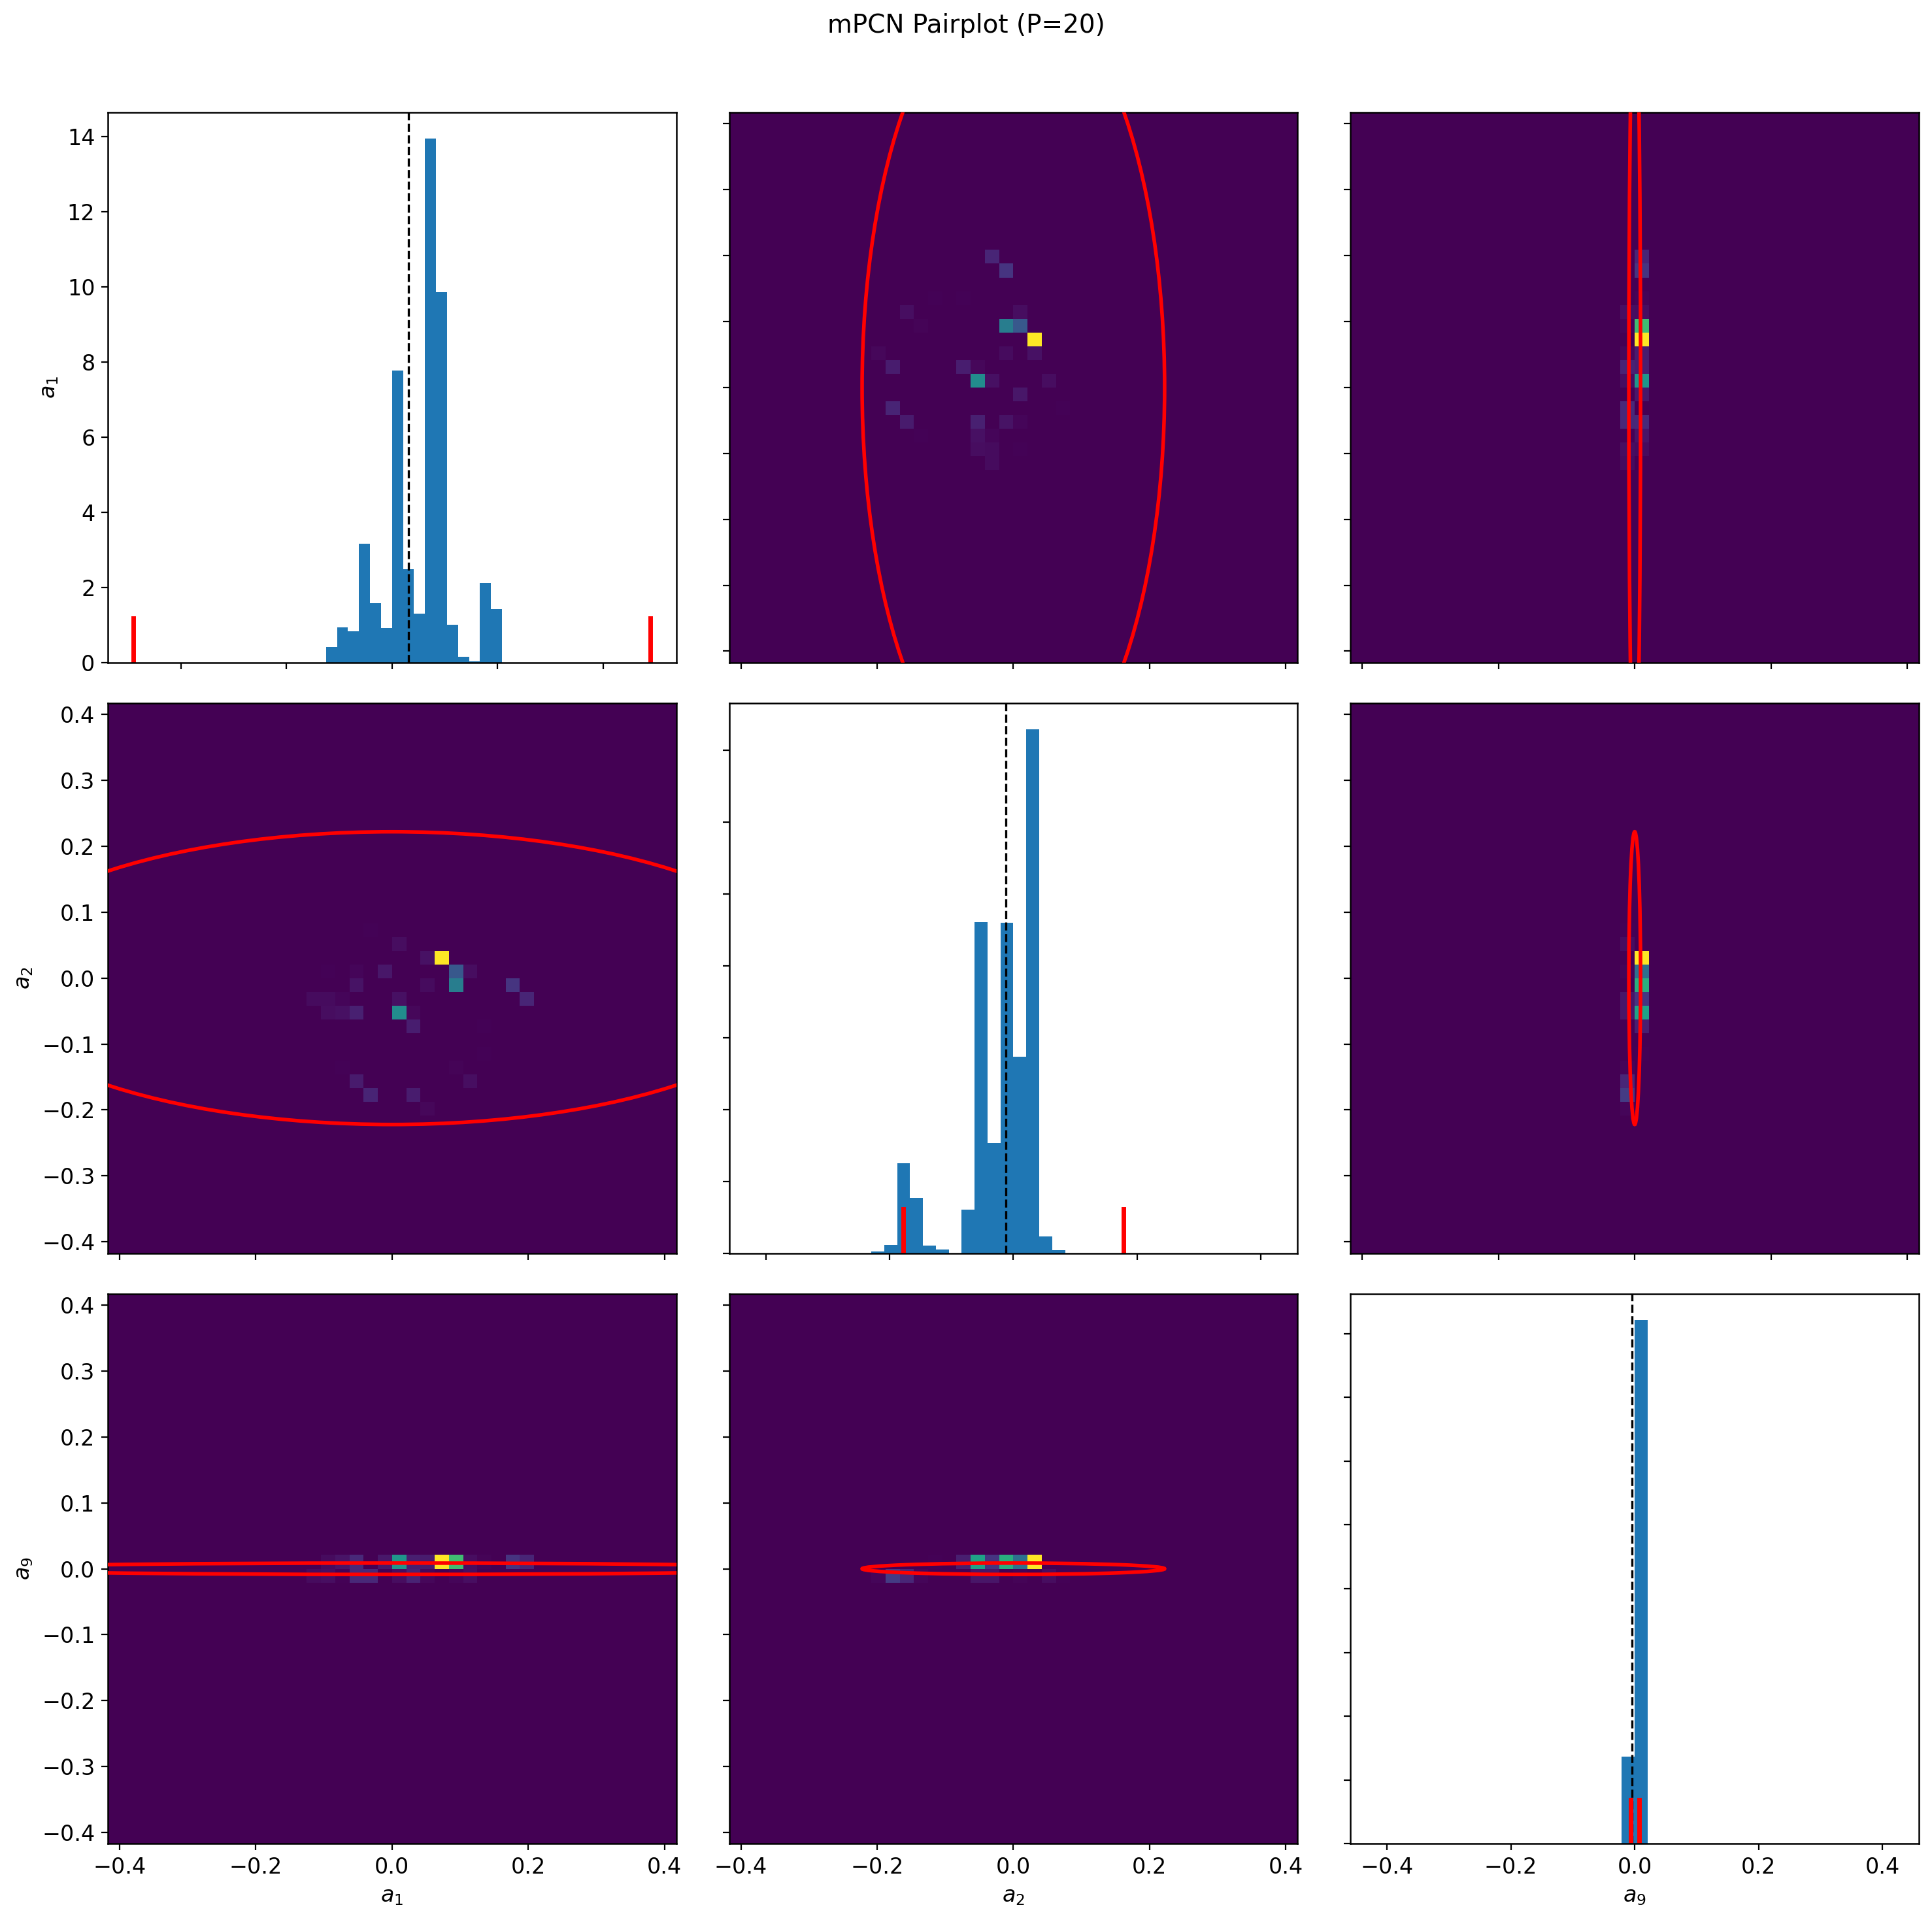

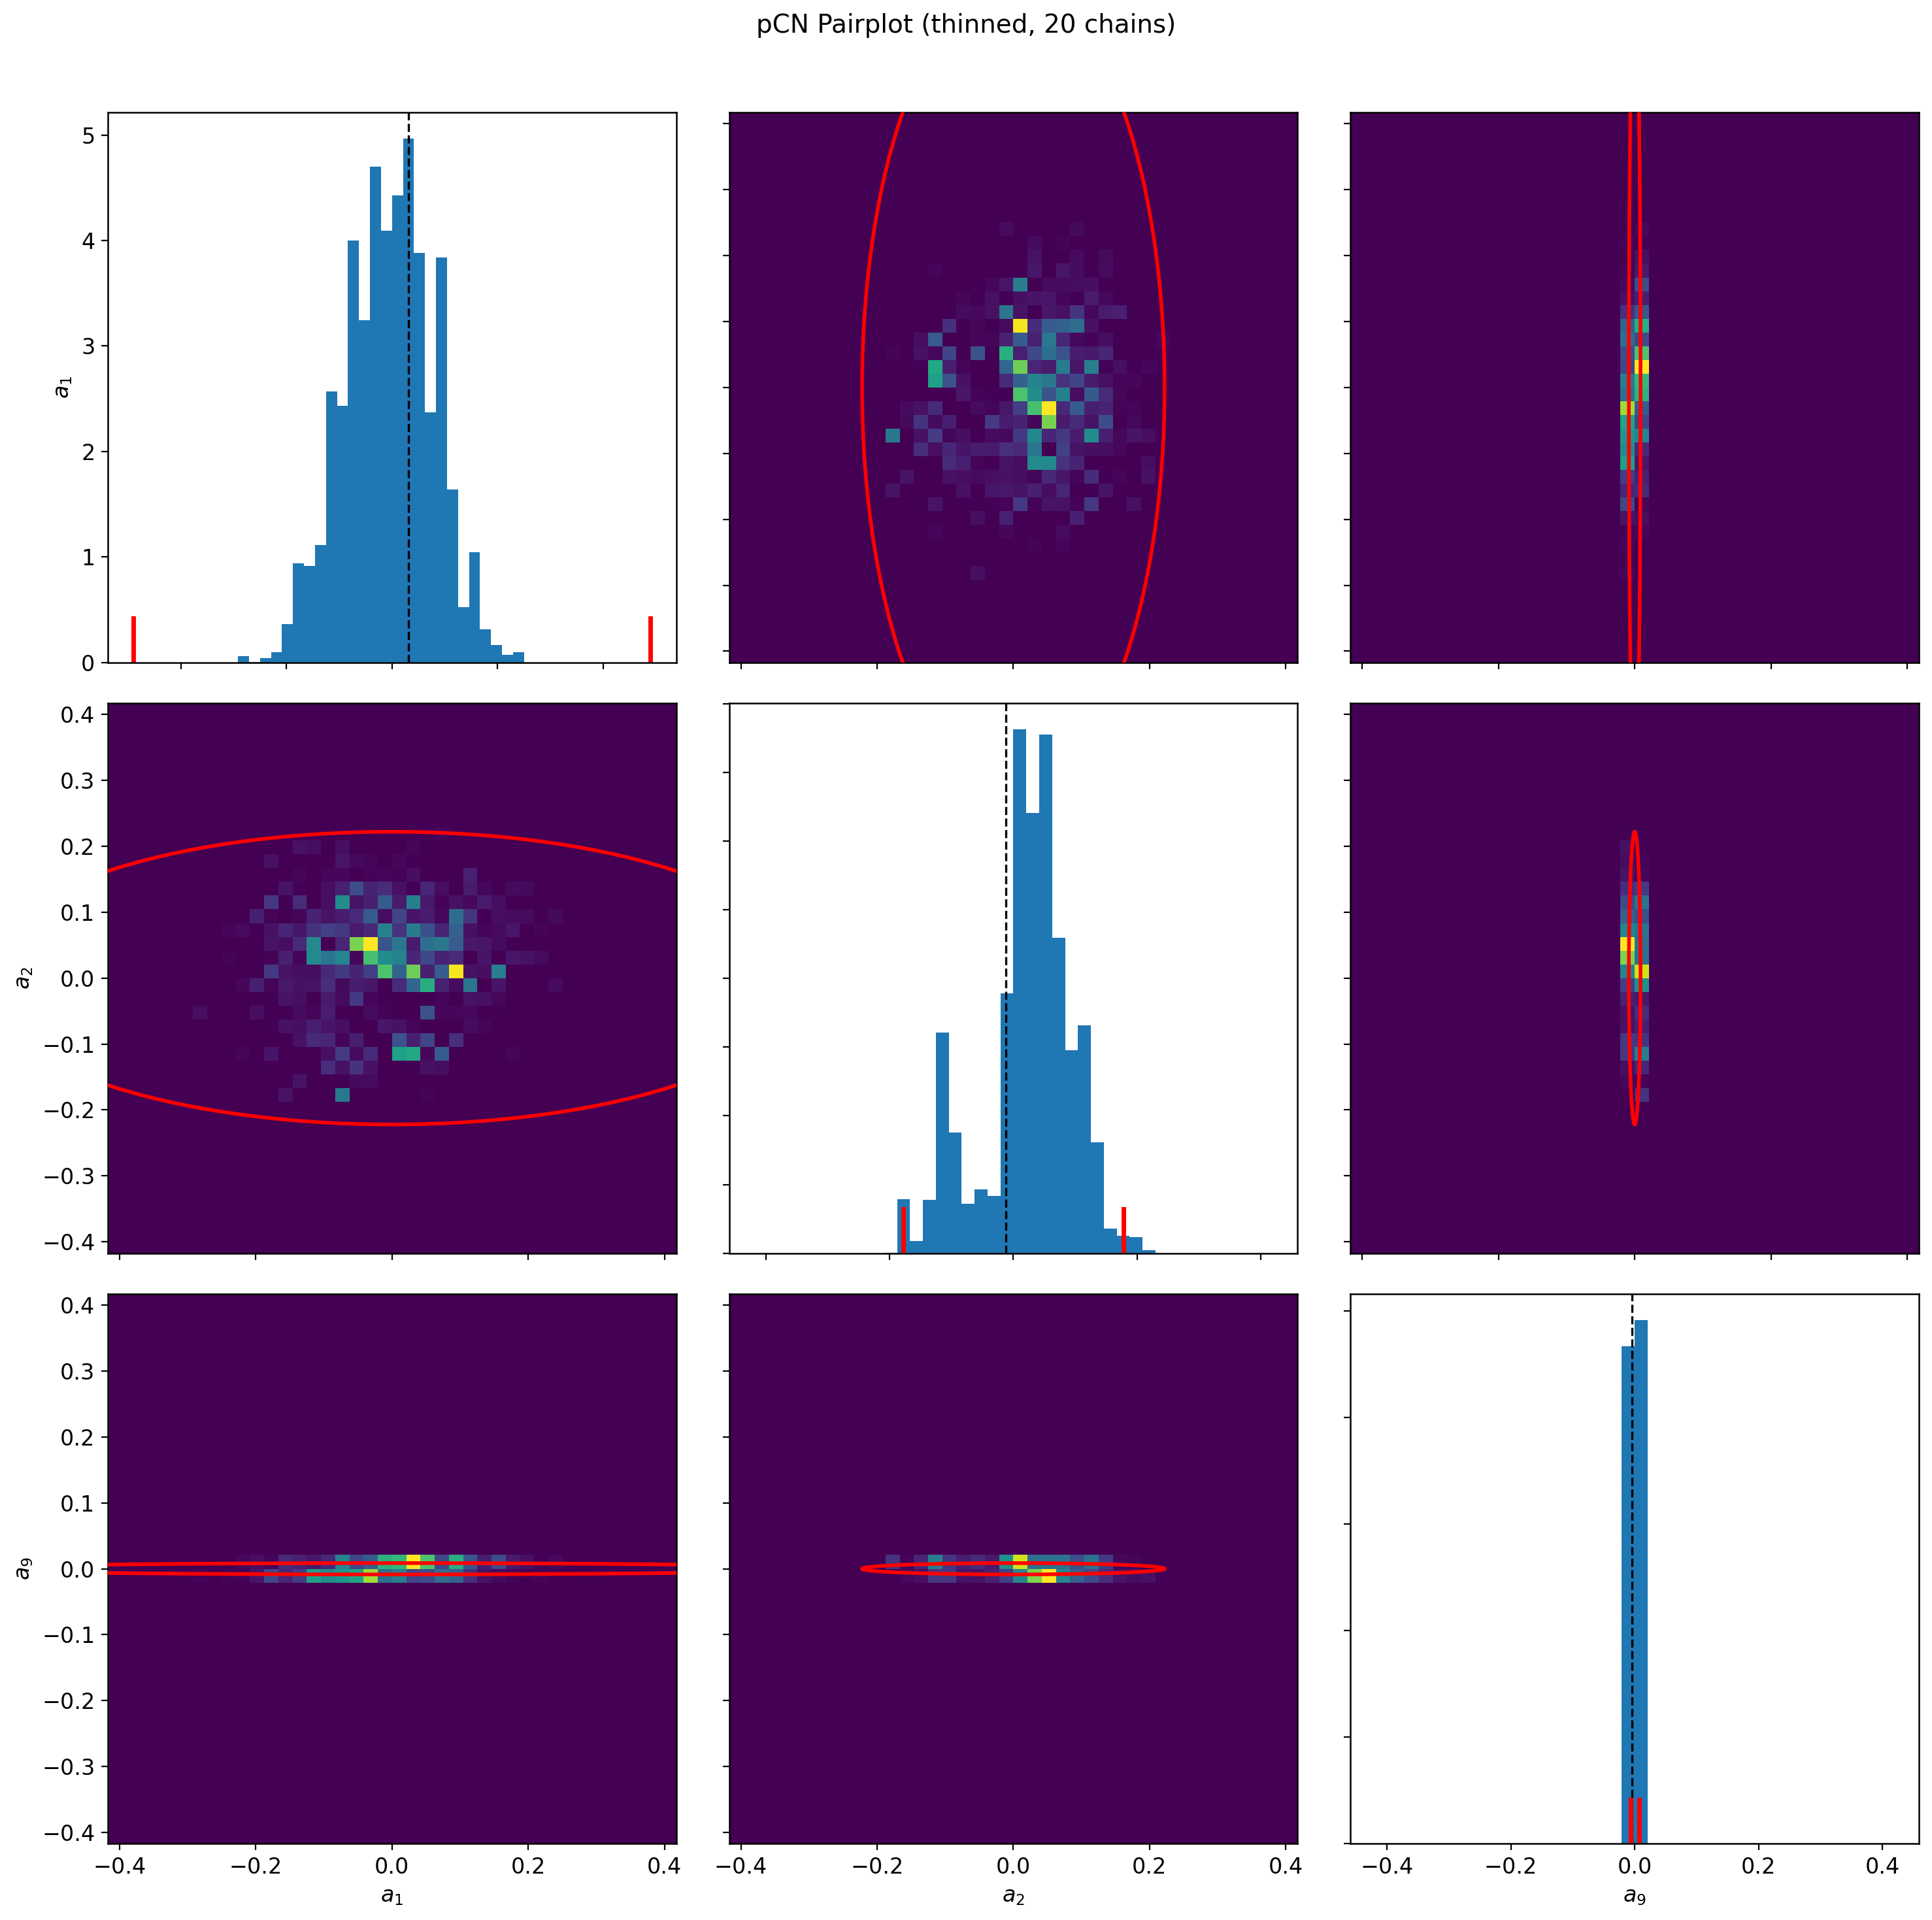

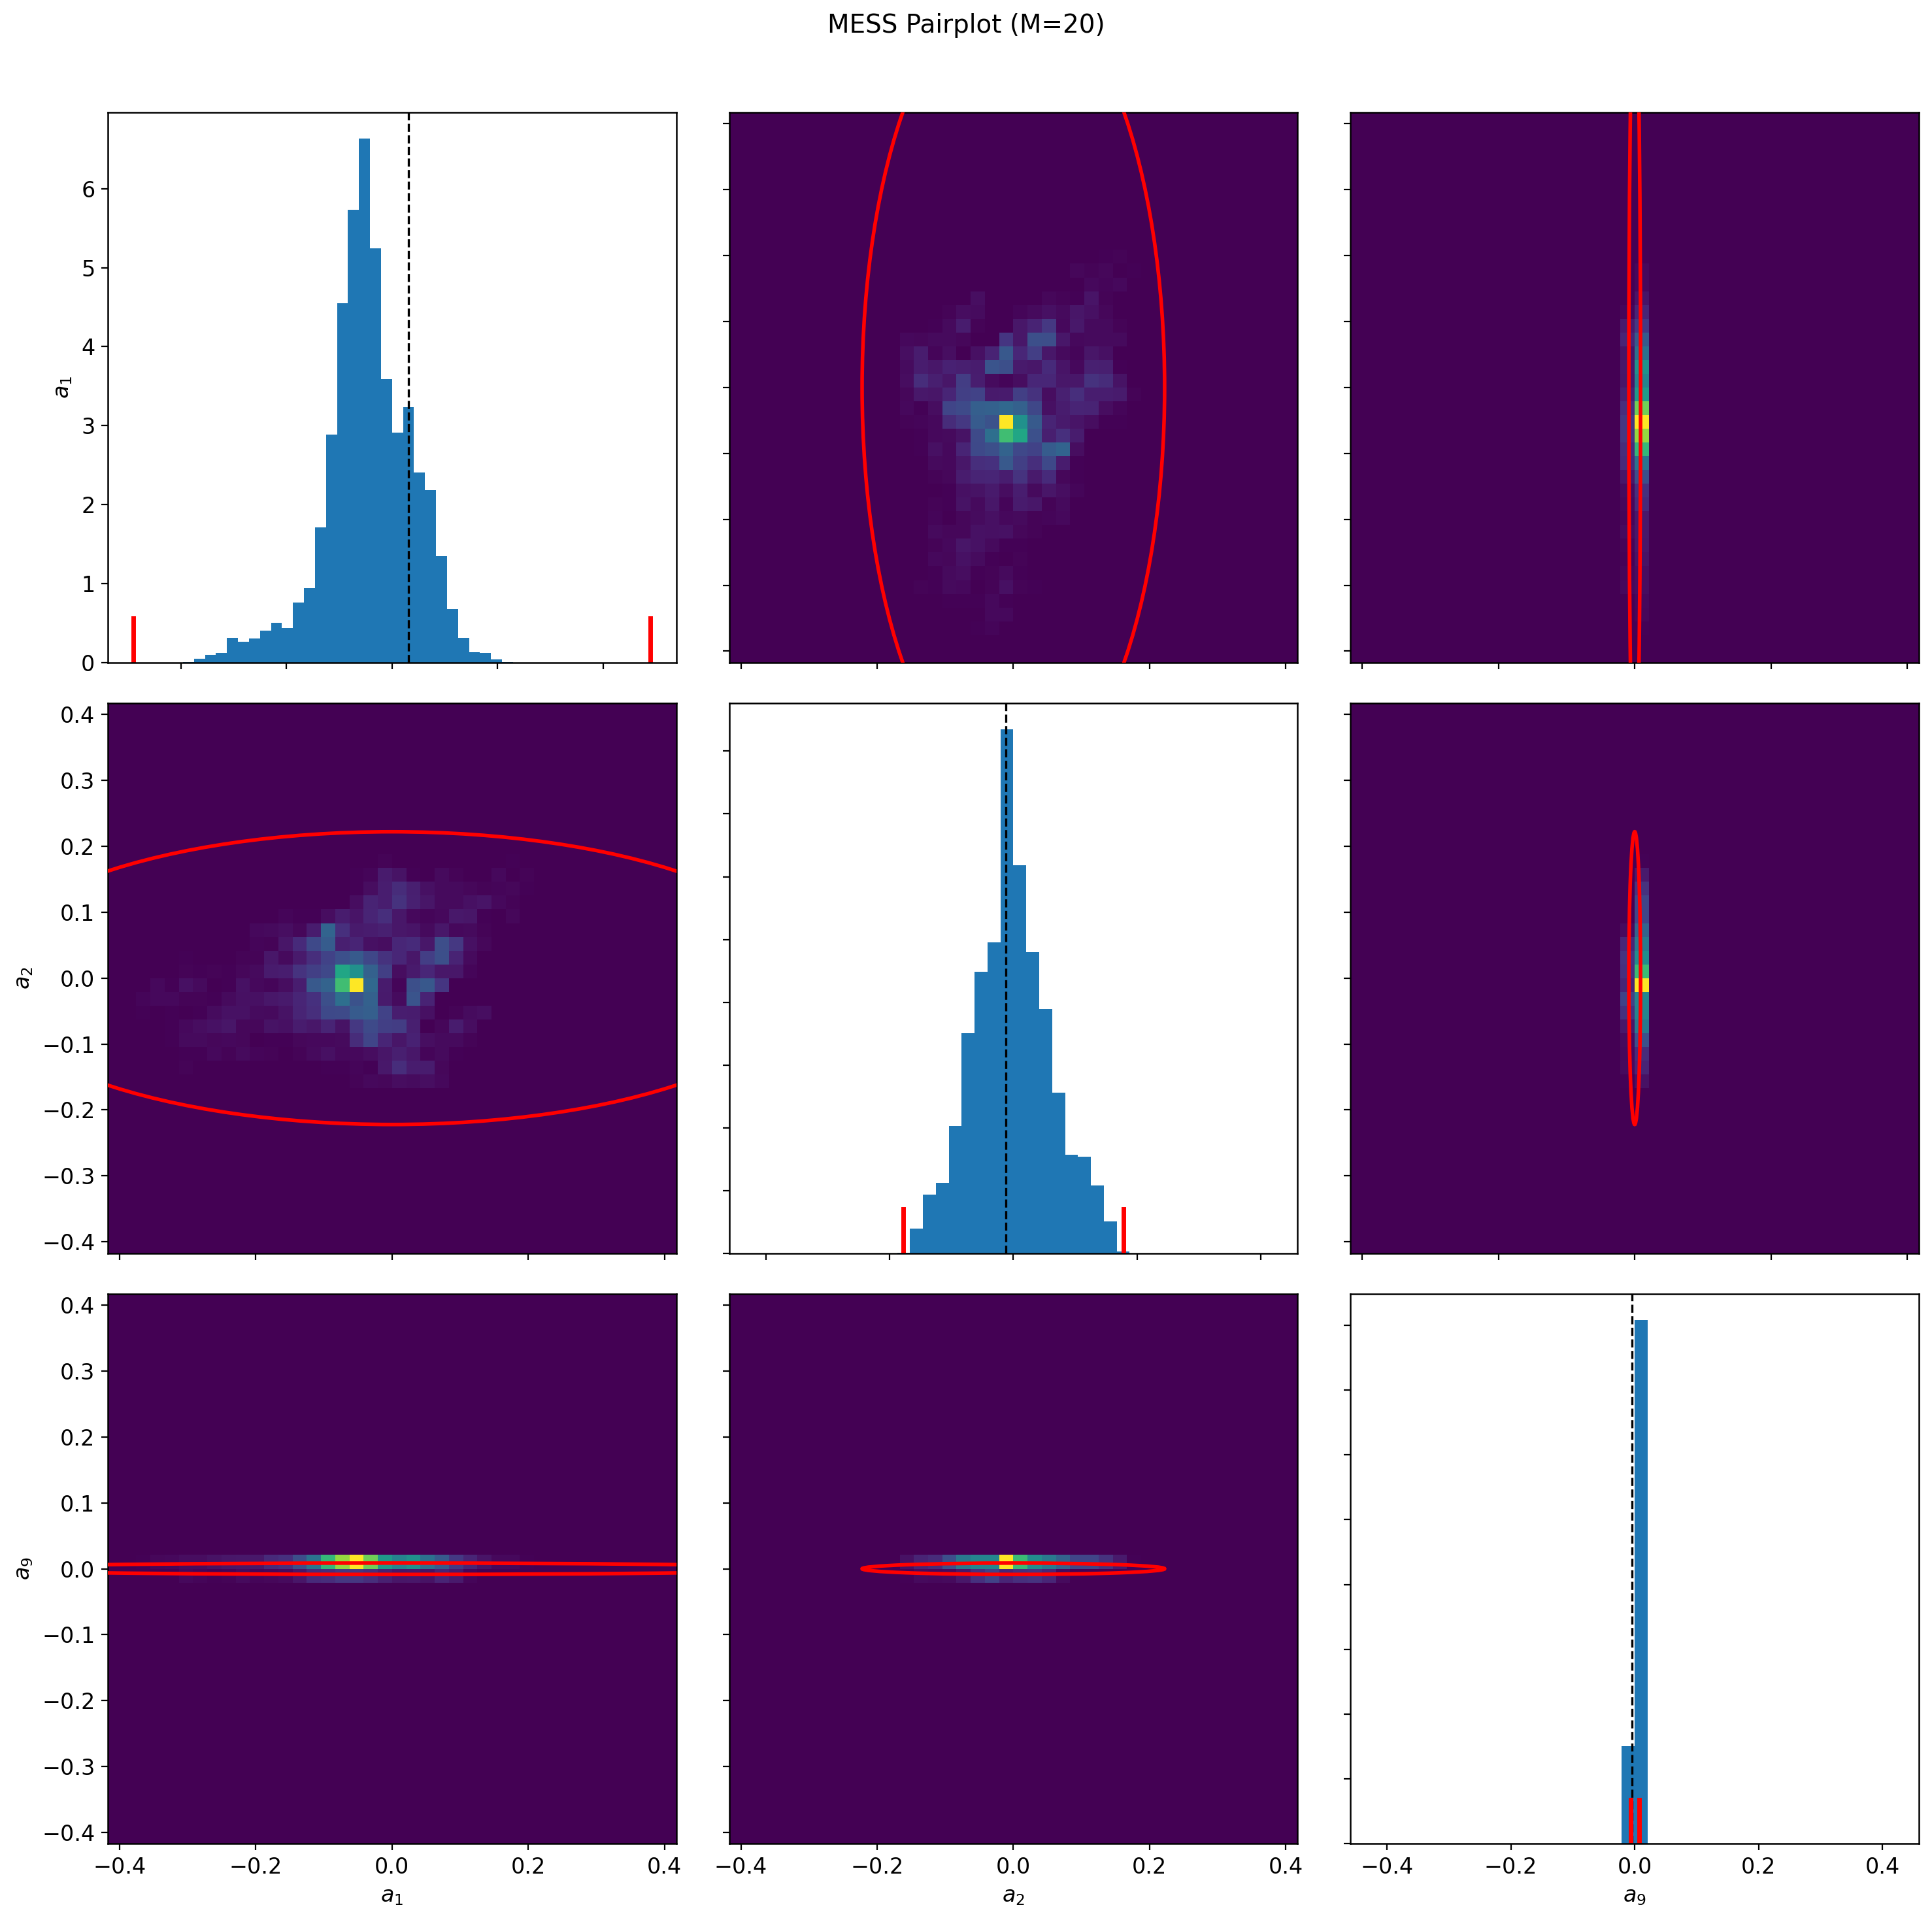

In [65]:
# Pairplots (main runs)
apply_pub_style()
burn_in_plot = burn_in
dr = 0.02
comp_list = [0, 1, 9]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 2:
    raise ValueError('Need at least two parameters for pairplots.')

post_chain_mpcn = chain_mpcn_joint[burn_in_plot:]
post_chain_mess = chain_mess[burn_in_plot:] if run_mess and chain_mess is not None else None

pcn_pair_samples = None
if run_pcn and pcn_chains is not None:
    pcn_pair_samples = np.vstack(
        [chain[burn_in_plot::pcn_thin_step] for chain in pcn_chains]
    )

combined_list = [post_chain_mpcn]
if pcn_pair_samples is not None:
    combined_list.append(pcn_pair_samples)
if post_chain_mess is not None:
    combined_list.append(post_chain_mess)
combined = np.vstack(combined_list)
R = 1.1 * np.max(np.abs(combined))
dr_plot = dr

label_map = {comp_list[0]: '$a_1$', comp_list[1]: '$a_2$'}
true_values = prior_sample

_ = make_hist_grid_comps(
    R=R,
    dr=dr_plot,
    samples=post_chain_mpcn,
    comp_list=comp_list,
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f'mPCN Pairplot (P={P_joint})',
    true_values=true_values,
 )

if pcn_pair_samples is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr_plot,
        samples=pcn_pair_samples,
        comp_list=comp_list,
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map=label_map,
        font_size=12,
        title=f'pCN Pairplot (thinned, {num_pcn_chains} chains)',
        true_values=true_values,
    )

if post_chain_mess is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr_plot,
        samples=post_chain_mess,
        comp_list=comp_list,
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map=label_map,
        font_size=12,
        title=f'MESS Pairplot (M={mess_M})',
        true_values=true_values,
    )

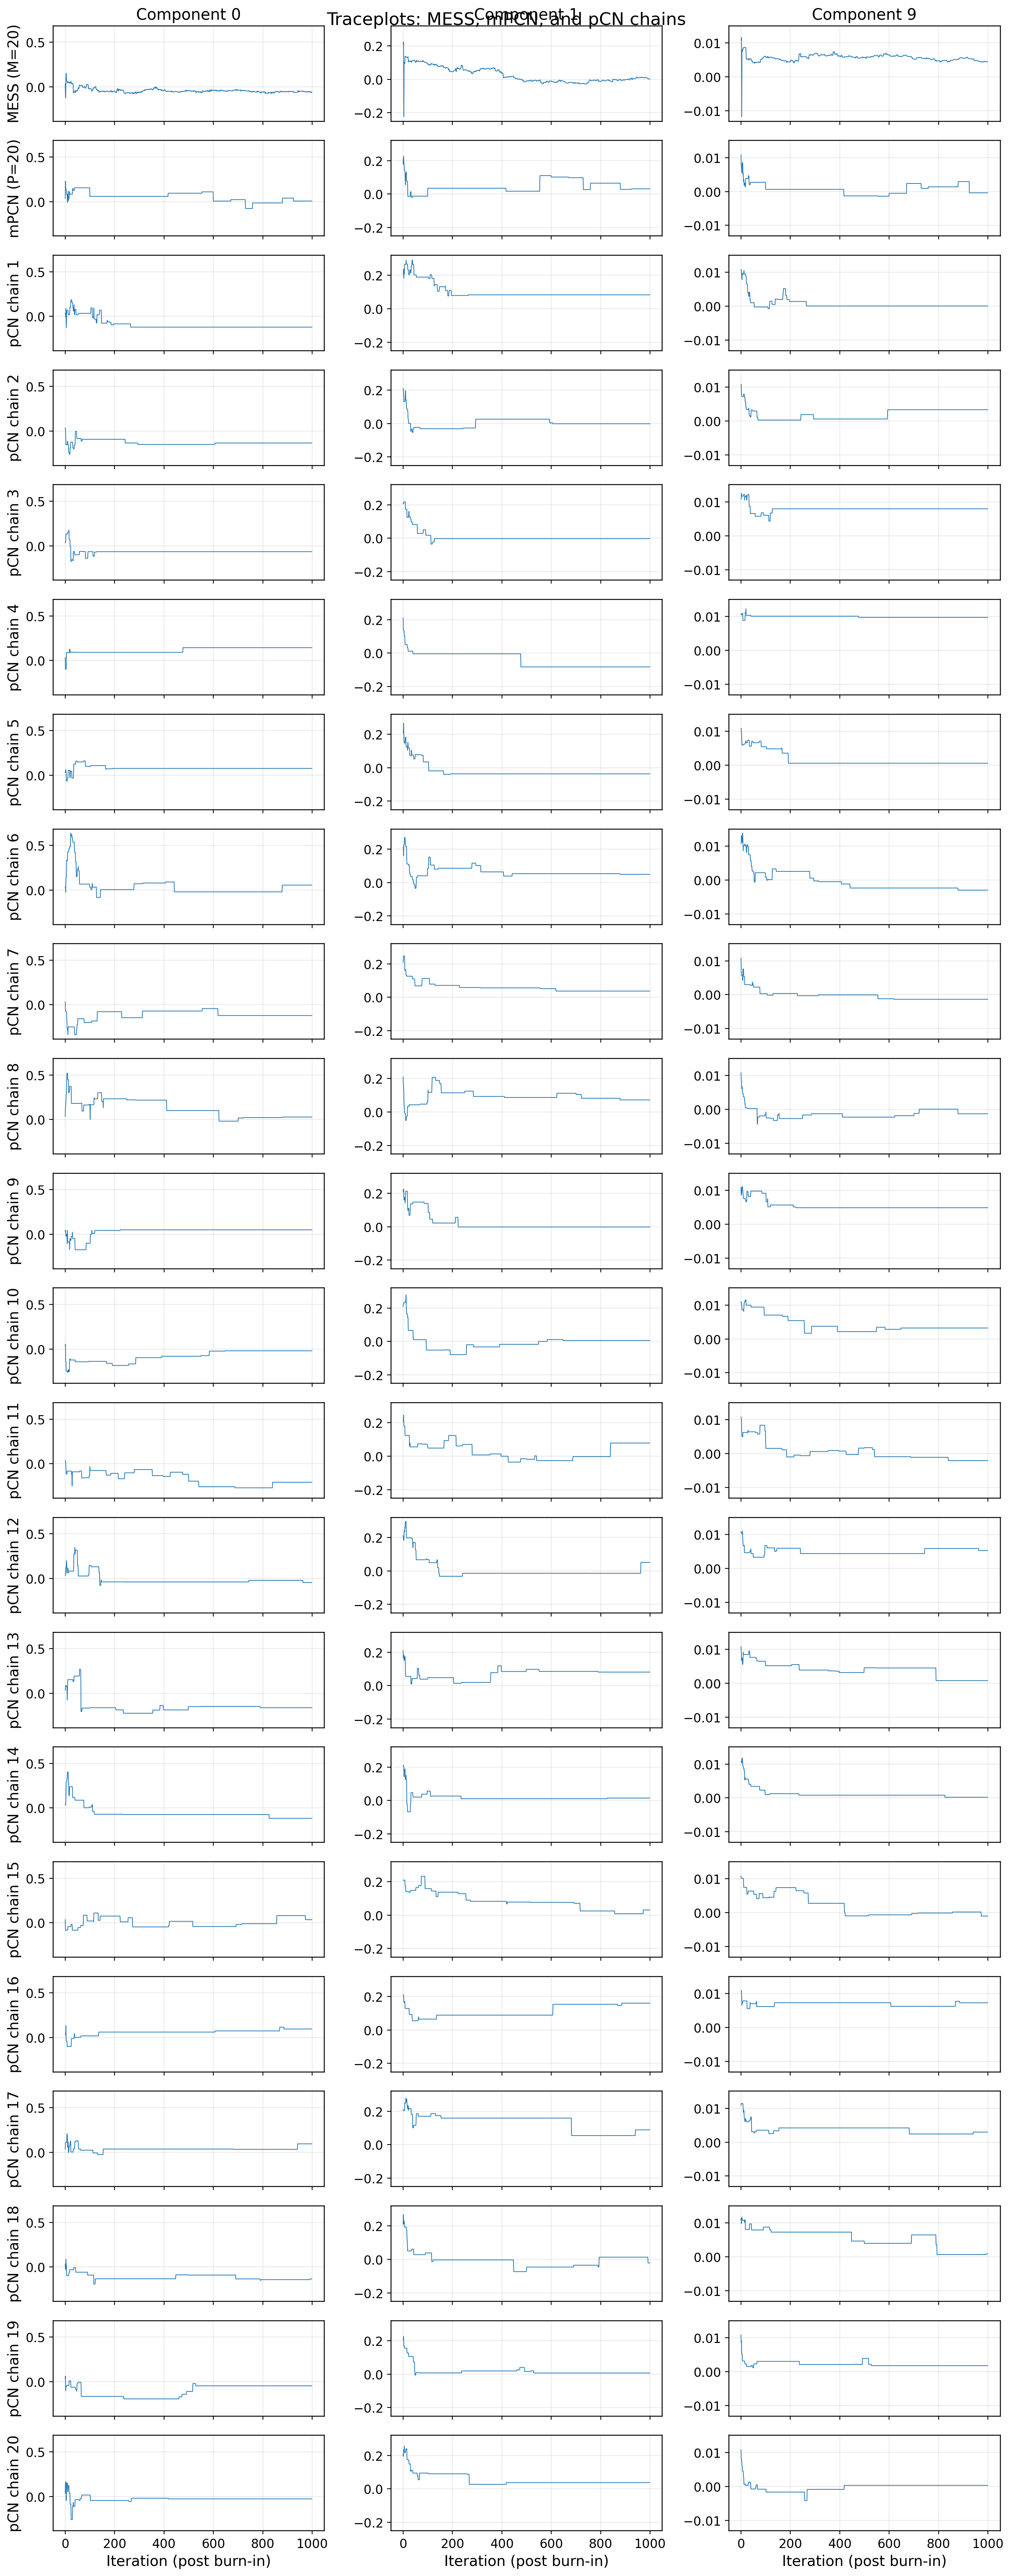

In [66]:
# Traceplots for components 0, 1, 9
comp_list = [0, 1, 9]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

trace_series = []
if run_mess and chain_mess is not None:
    trace_series.append((f'MESS (M={mess_M})', chain_mess))
trace_series.append((f'mPCN (P={P_joint})', chain_mpcn_joint))
if run_pcn and pcn_chains is not None:
    for i, chain in enumerate(pcn_chains):
        trace_series.append((f'pCN chain {i + 1}', chain))

nrows = len(trace_series)
ncols = len(comp_list)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.6 * ncols, 1.6 * nrows),
    sharex=True,
    sharey='col',
 )
if nrows == 1:
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, None]

for row_idx, (label, chain) in enumerate(trace_series):
    post_chain = chain[0:1000]
    for col_idx, comp in enumerate(comp_list):
        ax = axes[row_idx, col_idx]
        ax.plot(post_chain[:, comp], linewidth=0.7, color='tab:blue')
        if row_idx == 0:
            ax.set_title(f'Component {comp}')
        if col_idx == 0:
            ax.set_ylabel(label)
        ax.grid(alpha=0.25)
for ax in axes[-1, :]:
    ax.set_xlabel('Iteration (post burn-in)')

fig.suptitle('Traceplots: MESS, mPCN, and pCN chains')
fig.tight_layout()
plt.show()

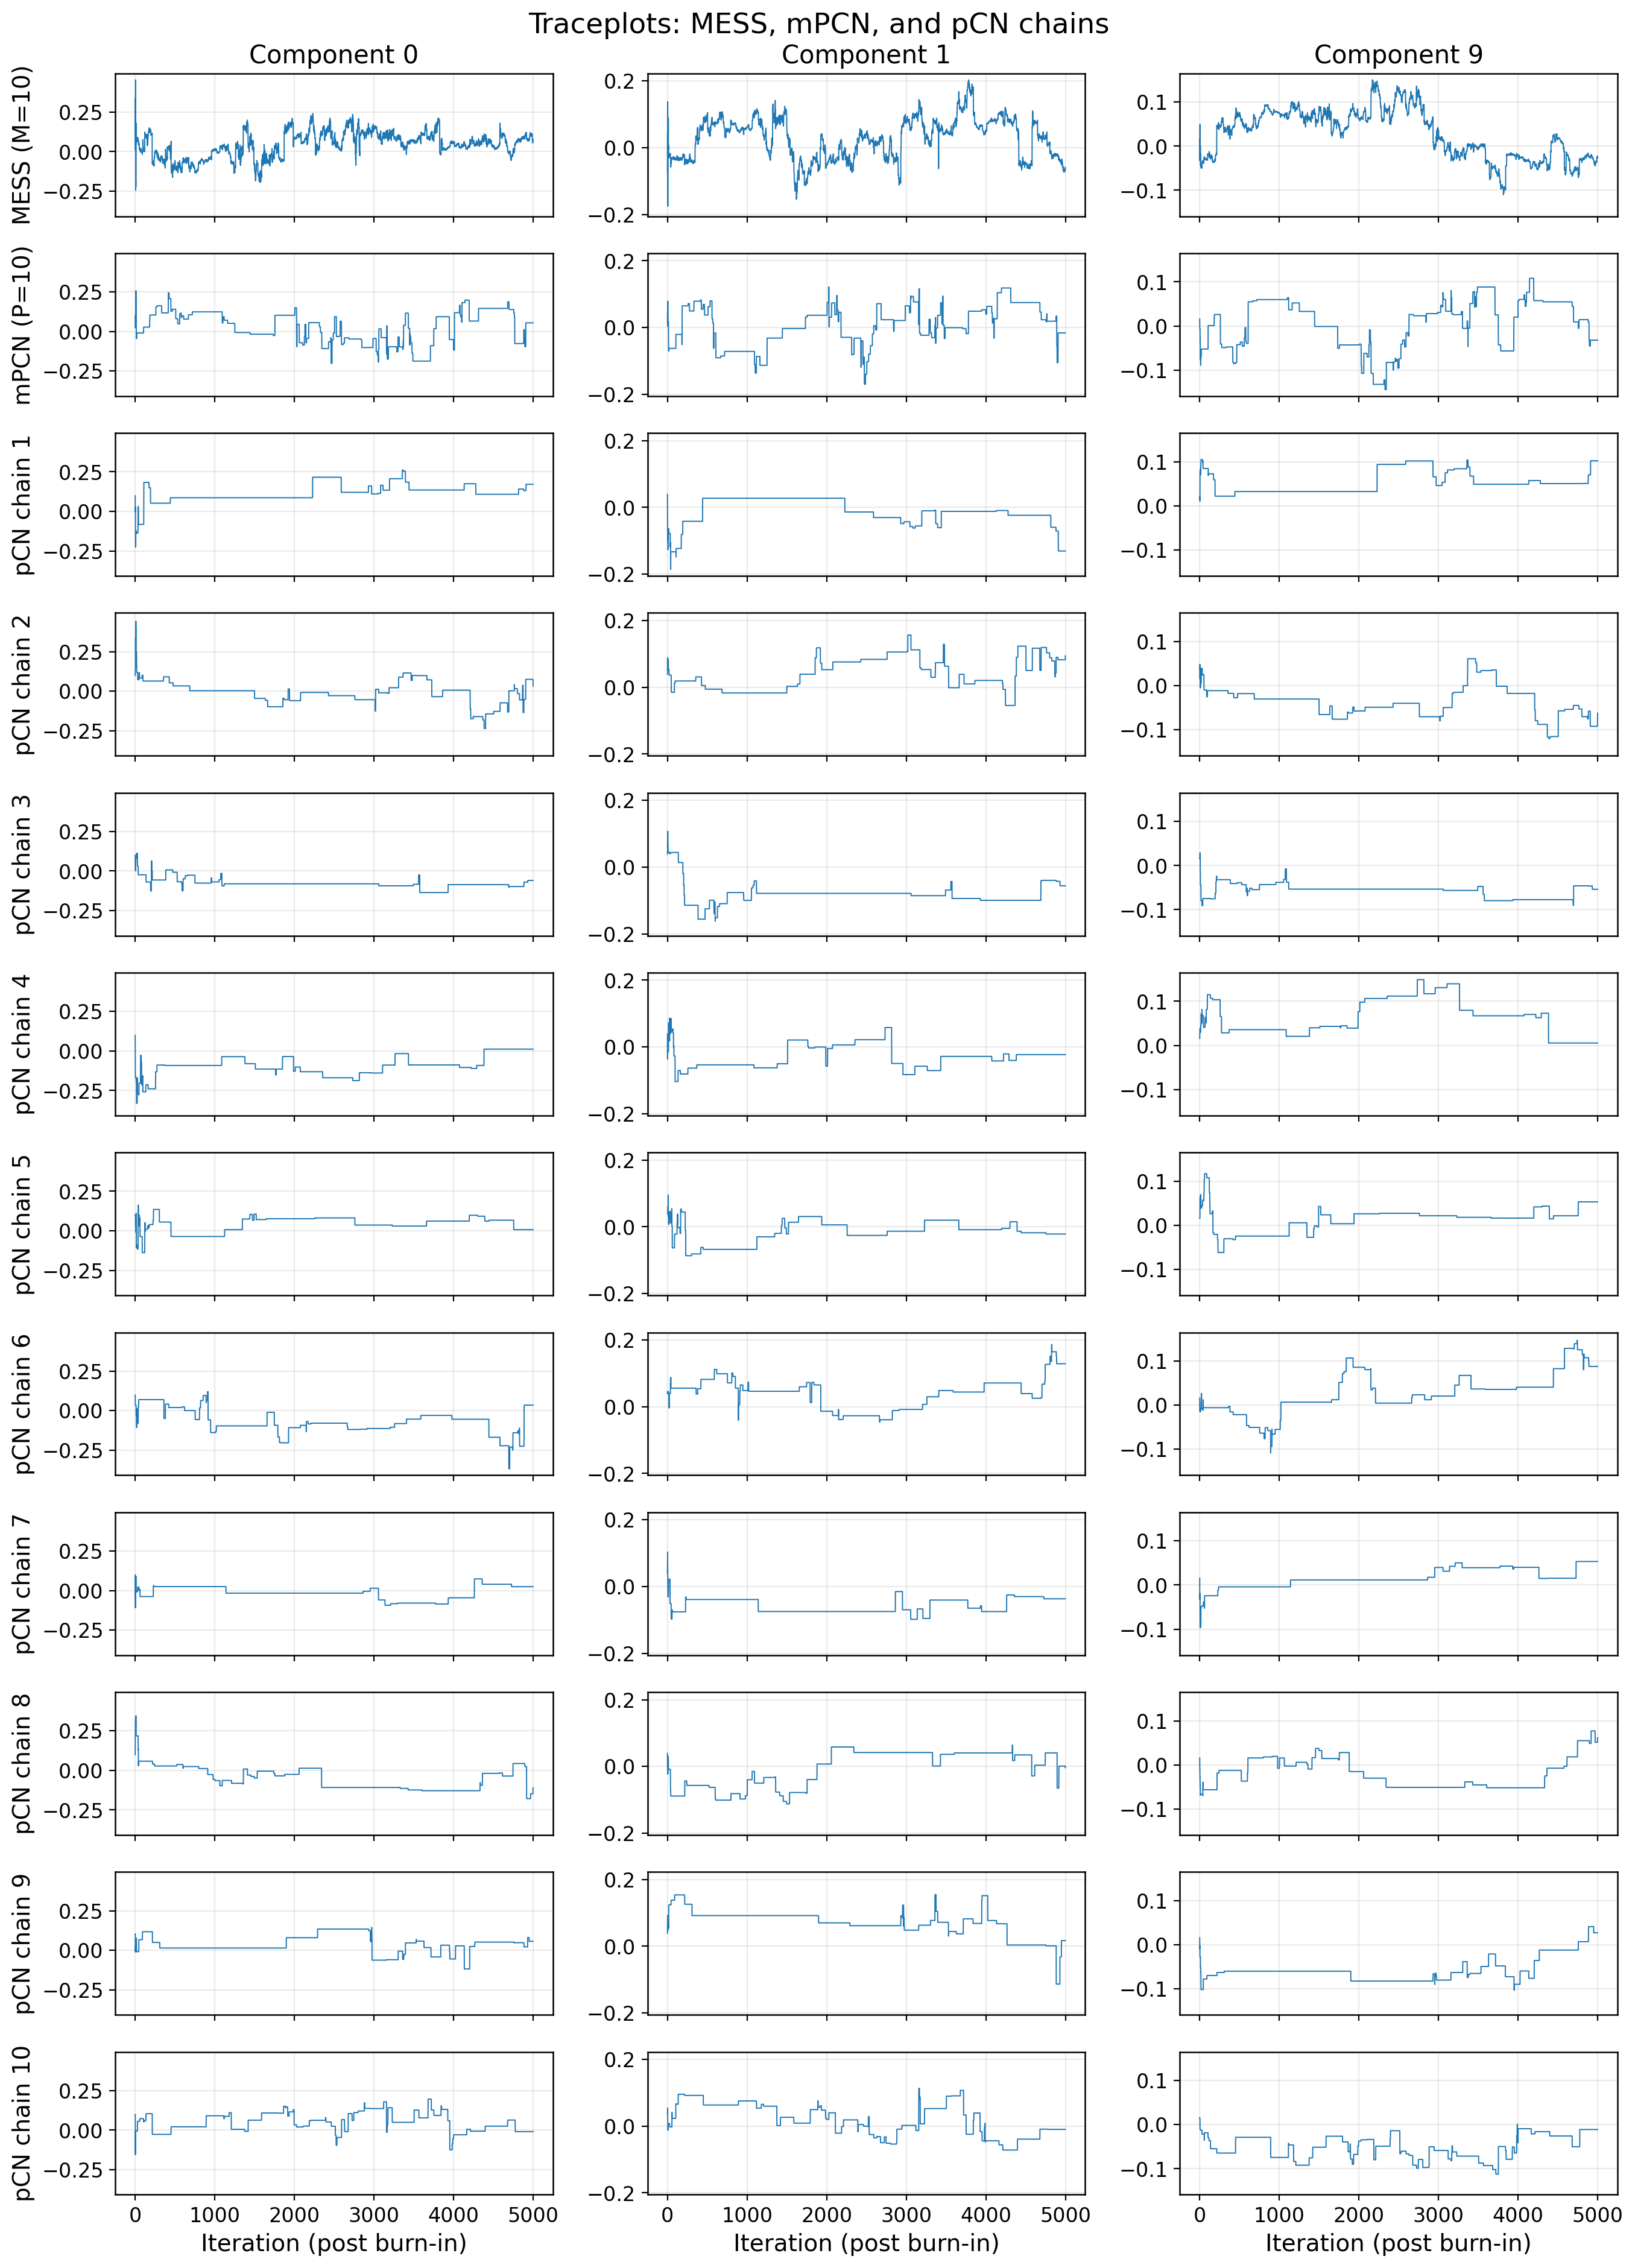

In [29]:
# Traceplots for components 0, 1, 9
comp_list = [0, 1, 9]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

trace_series = []
if run_mess and chain_mess is not None:
    trace_series.append((f'MESS (M={mess_M})', chain_mess))
trace_series.append((f'mPCN (P={P_joint})', chain_mpcn_joint))
if run_pcn and pcn_chains is not None:
    for i, chain in enumerate(pcn_chains):
        trace_series.append((f'pCN chain {i + 1}', chain))

nrows = len(trace_series)
ncols = len(comp_list)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.6 * ncols, 1.6 * nrows),
    sharex=True,
    sharey='col',
 )
if nrows == 1:
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, None]

for row_idx, (label, chain) in enumerate(trace_series):
    post_chain = chain[0:5000]
    for col_idx, comp in enumerate(comp_list):
        ax = axes[row_idx, col_idx]
        ax.plot(post_chain[:, comp], linewidth=0.7, color='tab:blue')
        if row_idx == 0:
            ax.set_title(f'Component {comp}')
        if col_idx == 0:
            ax.set_ylabel(label)
        ax.grid(alpha=0.25)
for ax in axes[-1, :]:
    ax.set_xlabel('Iteration (post burn-in)')

fig.suptitle('Traceplots: MESS, mPCN, and pCN chains')
fig.tight_layout()
plt.show()

In [ ]:
# Save results to estimations folder
data_config = {
    'seed_data': seed_data,
    'd': d,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config,
}
algo_config = {
    'n_iters': n_iters,
    'rho': rho,
    'P_joint': P_joint,
    'num_pcn_chains': num_pcn_chains,
    'mess_M': mess_M,
    'run_mess': run_mess,
    'run_pcn': run_pcn,
    'burn_in': burn_in,
    'max_lag': max_lag,
    'seed_mcmc': seed_mcmc,
}
tag_parts = [
    f"d{d}",
    f"P{P_joint}",
    f"rho{format_float_tag(rho)}",
    f"iters{n_iters}",
    f"seed{seed_mcmc}",
],
estimations_dir, reports_dir, run_name, run_config = build_run_dirs(
    repo_root,
    dataset='solute_transport',
    algorithm='mpcn_independent_chains',
    data_config=data_config,
    algorithm_config=algo_config,
    tag_parts=tag_parts,
 )

mpcn_path = estimations_dir / f"mpcn_P{P_joint}_rho{format_float_tag(rho)}_seed{seed_mcmc}.npz"
pcn_path = estimations_dir / f"pcn_rho{format_float_tag(rho)}_seed{seed_mcmc}.npz"
mess_path = estimations_dir / f"mess_M{mess_M}_seed{seed_mcmc}.npz"

np.savez_compressed(
    mpcn_path,
    chain=chain_mpcn_joint,
    accepted_index=accepted_index_joint,
    runtime_sec=runtime_mpcn_joint_sec,
    accept_rate=accept_rate_joint,
    metrics=metrics_mpcn_joint,
 )

if run_pcn and pcn_chains is not None:
    np.savez_compressed(
        pcn_path,
        chain=chain_pcn,
        chains=pcn_chains,
        accept_rate_all=accept_rate_pcn_all,
        runtime_sec=runtime_pcn_sec,
        metrics=metrics_pcn,
        metrics_stack=metrics_pcn_stack,
    )

if run_mess and chain_mess is not None:
    np.savez_compressed(
        mess_path,
        chain=chain_mess,
        runtime_sec=runtime_mess_sec,
        metrics=metrics_mess,
    )

metrics_payload = {
    'mpcn_joint': metrics_mpcn_joint,
    'pcn': metrics_pcn,
    'pcn_stack': metrics_pcn_stack,
    'mess': metrics_mess,
    'runtime_mpcn_joint_sec': runtime_mpcn_joint_sec,
    'runtime_pcn_sec': runtime_pcn_sec,
    'runtime_mess_sec': runtime_mess_sec,
    'accept_rate_joint': accept_rate_joint,
    'accept_rate_pcn_all': accept_rate_pcn_all,
    'num_pcn_chains': num_pcn_chains,
    'run_name': run_name,
}
with open(estimations_dir / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2)

print('Saved run to:', estimations_dir)

Saved run to: /home/senng/multiproposal-internal/estimations/solute_transport/mpcn_independent/solute_transport_mpcn_ind_P10_rho0.9_iters40000_seed202_h2788fb695681
